[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoBasicoIME/blob/main/09_metodo_combinado.ipynb)

# Ajustamento Básico - Modelos clássicos de ajustamento

**Maj Diego - 2° Semestre / 2026**

**Objetivos:**

1. 1. Apresentar e entender aplicações para o Modelo Combinado

**Referência:** Gilbert Strang, Kai Borre (1997). *Linear Algebra, Geodesy, and GPS*. Wellesley-Cambridge Press. $\rightarrow$ **Cap 6, 7, 8 e 9**


## O Problema

Até aqui, o método dos mínimos quadrados (MMQ) foi sempre aplicado a um caso particular: as observações escritas explicitamente como função dos parâmetros desconhecidos, $F(X_a)=L_b$, o **Modelo Paramétrico**.

Esse, no entanto, é só um caso dentre três situações possíveis, que diferem em **o que aparece como incógnita** na equação de ajustamento:

| $\begin{matrix}\text{Situação}\end{matrix}$ | $\begin{matrix}\text{Equação}\end{matrix}$ | $\begin{matrix}\text{Modelo}\end{matrix}$ |
|---|---|---|
| As observações ajustadas podem ser escritas em função de parâmetros | $F(X_a) = L_b$ | **Paramétrico** |
| Não há parâmetros explícitos; as próprias observações ajustadas devem satisfazer uma condição geométrica/física | $F(L_a) = 0$ | **Condicionado** |
| Parâmetros e observações ajustadas aparecem juntos, sem que seja possível isolar um em função do outro | $F(X_a, L_a) = 0$ | **Combinado** |

## 1. Revisar o Modelo Paramétrico

No **Modelo Paramétrico**, <b style="color:#2ECC40">cada observação é modelada como função de parâmetros desconhecidos</b>. 

É o modelo natural quando se deseja estimar grandezas como coordenadas, alturas, coeficientes de uma reta, parâmetros de transformação ou qualquer conjunto de incógnitas que explique as observações.

## 3. Apresentar e entender aplicações para o Modelo Combinado

O **Modelo Combinado** é o caso mais geral dos modelos clássicos, pois envolve simultaneamente parâmetros desconhecidos e observações ajustadas. Sua forma funcional é

$$
F(X_a,L_a)=0.
$$

Ele é usado quando as equações do problema não permitem escrever diretamente todas as observações apenas em função dos parâmetros, nem apenas impor condições entre observações. Um exemplo típico é o ajustamento de uma circunferência quando as coordenadas dos pontos observados recebem correções e, ao mesmo tempo, são estimados o centro e o raio.

No caso linearizado, usando $X_a=X_0+X$ e $L_a=L_b+V$, obtém-se

$$
A X + B V + W = 0,
$$

em que

$$
A=\frac{\partial F}{\partial X_a}, \qquad B=\frac{\partial F}{\partial L_a}, \qquad W=F(X_0,L_b)
$$

na primeira linearização. Para $m$ equações, $n$ parâmetros e $r$ observações, a redundância é

$$
f = r-m+n,
$$

devendo-se ter $f>0$, ou equivalentemente $r>m-n$.

A solução pode ser escrita com

$$
M=BP^{-1}B^T.
$$

A partir das equações normais do modelo combinado, obtém-se

$$
X=-(A^TM^{-1}A)^{-1}A^TM^{-1}W.
$$

Em seguida,

$$
K=-M^{-1}(AX+W)
$$

e

$$
V=P^{-1}B^TK.
$$

Finalmente,

$$
X_a=X_0+X, \qquad L_a=L_b+V.
$$

Quando o modelo é não linear, repetem-se as linearizações. De modo análogo ao modelo condicionado, o vetor de fechamento passa a considerar a solução ajustada da iteração anterior:

$$
A_iX_i+B_iV_i+B_i(L_b-L_a^{i-1})+F(X_a^{i-1},L_a^{i-1})=0.
$$

O processo termina quando as correções dos parâmetros e das observações se tornam insignificantes ou quando a forma $V^TPV$ se estabiliza.

### Exemplo simples - Modelo Combinado

Considere duas observações independentes de uma mesma grandeza $X$, com pesos iguais:

$$
L_b=\begin{bmatrix}10,1\\10,4\end{bmatrix}, \qquad X_0=10,0.
$$

Queremos estimar o valor ajustado $X_a$ e também corrigir as observações. As equações do modelo combinado são

$$
F_1(X_a,L_a)=L_{a1}-X_a=0, \qquad F_2(X_a,L_a)=L_{a2}-X_a=0.
$$

Como $X_a=X_0+X$ e $L_a=L_b+V$, a forma linearizada é

$$
AX+BV+W=0.
$$

Neste caso,

$$
A=\begin{bmatrix}-1\\-1\end{bmatrix}, \qquad B=\begin{bmatrix}1&0\\0&1\end{bmatrix}, \qquad W=F(X_0,L_b)=\begin{bmatrix}0,1\\0,4\end{bmatrix}.
$$

Com $P=I$, tem-se

$$
M=BP^{-1}B^T=I.
$$

A correção do parâmetro é

$$
X=-(A^TM^{-1}A)^{-1}A^TM^{-1}W.
$$

Calculando:

$$
A^TA=2, \qquad A^TW=(-1)(0,1)+(-1)(0,4)=-0,5,
$$

portanto,

$$
X=-\frac{1}{2}(-0,5)=0,25.
$$

Assim,

$$
X_a=X_0+X=10,25.
$$

Agora,

$$
K=-M^{-1}(AX+W)=-\left(\begin{bmatrix}-0,25\\-0,25\end{bmatrix}+\begin{bmatrix}0,1\\0,4\end{bmatrix}\right)=\begin{bmatrix}0,15\\-0,15\end{bmatrix}.
$$

Logo,

$$
V=P^{-1}B^TK=\begin{bmatrix}0,15\\-0,15\end{bmatrix}.
$$

As observações ajustadas são

$$
L_a=L_b+V=\begin{bmatrix}10,25\\10,25\end{bmatrix}.
$$

Verificação:

$$
L_{a1}-X_a=10,25-10,25=0, \qquad L_{a2}-X_a=10,25-10,25=0.
$$

Este exemplo é pequeno de propósito: ele mostra que, no modelo combinado, as observações e os parâmetros são ajustados ao mesmo tempo para satisfazer as equações do problema.

### Exemplo — Ajuste de circunferência (Modelo Combinado)

Dadas as coordenadas observadas de 4 pontos, deseja-se estimar a circunferência (centro $X_C, Y_C$ e raio $r$) que melhor se ajusta a eles. Como **tanto os parâmetros quanto as observações ($X_i, Y_i$) recebem correções**, este é um problema clássico do **Modelo Combinado**:

$$
F_n(X_a, L_a) = (X_n - X_C)^2 + (Y_n - Y_C)^2 - r^2 = 0, \quad n=1,\dots,4
$$

$$
A = \frac{\partial F}{\partial X_a}, \qquad B = \frac{\partial F}{\partial L_a}, \qquad W = F(X_0, L_b)
$$

$$
M = BP^{-1}B^T, \qquad X = -(A^TM^{-1}A)^{-1}A^TM^{-1}W, \qquad K=-M^{-1}(AX+W), \qquad V = P^{-1}B^TK
$$

Solução inicial sugerida: $X_0 = (x_0, y_0, r_0) = (100, 120, 70)$.

In [1]:
import numpy as np

# Pontos observados (X, Y) e variâncias
pts = np.array([[140,60],[165,100],[165,150],[140,180]], dtype=float)
var_x = np.array([2,4,2,4], dtype=float)
var_y = np.array([2,4,2,4], dtype=float)

n_pts = len(pts)
Lb = pts.flatten()  # [x1,y1,x2,y2,x3,y3,x4,y4]
P = np.diag(np.repeat(1.0, 2*n_pts))
for i in range(n_pts):
    P[2*i, 2*i] = 1.0/var_x[i]
    P[2*i+1, 2*i+1] = 1.0/var_y[i]

X0 = np.array([100.0, 120.0, 70.0])  # Xc, Yc, r

def F_comb(Xp, L):
    Xc, Yc, r = Xp
    Xs = L[0::2]; Ys = L[1::2]
    return (Xs-Xc)**2 + (Ys-Yc)**2 - r**2

def A_mat(Xp, L):
    Xc, Yc, r = Xp
    Xs = L[0::2]; Ys = L[1::2]
    rows = []
    for x,y in zip(Xs, Ys):
        rows.append([-2*(x-Xc), -2*(y-Yc), -2*r])
    return np.array(rows)

def B_mat(Xp, L):
    Xc, Yc, r = Xp
    Xs = L[0::2]; Ys = L[1::2]
    B = np.zeros((n_pts, 2*n_pts))
    for i,(x,y) in enumerate(zip(Xs, Ys)):
        B[i, 2*i]   = 2*(x-Xc)
        B[i, 2*i+1] = 2*(y-Yc)
    return B

Xp = X0.copy()
Lb_work = Lb.copy()
hist = [Xp.copy()]
for it in range(10):
    W = F_comb(Xp, Lb_work)
    A = A_mat(Xp, Lb_work)
    B = B_mat(Xp, Lb_work)
    M = B @ np.linalg.inv(P) @ B.T
    Minv = np.linalg.inv(M)
    X_corr = -np.linalg.inv(A.T @ Minv @ A) @ (A.T @ Minv @ W)
    Xp = Xp + X_corr
    K = -Minv @ (A @ X_corr + W)
    V = np.linalg.inv(P) @ B.T @ K
    La = Lb + V          # Lb original NUNCA é atualizado
    hist.append(Xp.copy())
    if np.max(np.abs(X_corr)) < 1e-4:
        break

print(f"Convergiu em {it+1} iterações")
print(f"Centro ajustado: Xc = {Xp[0]:.3f} m, Yc = {Xp[1]:.3f} m")
print(f"Raio ajustado:   r  = {Xp[2]:.3f} m")
print(f"\nResíduos V (m):\n{np.round(V,4).reshape(-1,2)}")

Convergiu em 5 iterações
Centro ajustado: Xc = 94.051 m, Yc = 120.748 m
Raio ajustado:   r  = 75.766 m

Resíduos V (m):
[[-0.242   0.32  ]
 [ 1.7937 -0.5245]
 [-0.8969 -0.3698]
 [ 0.484   0.6242]]


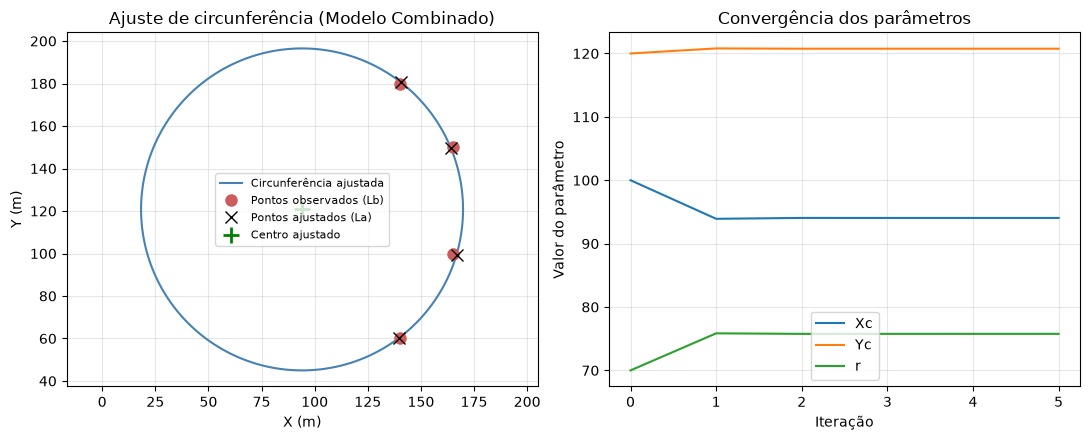

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11,4.5))

theta = np.linspace(0, 2*np.pi, 200)
Xc, Yc, r = Xp
ax[0].plot(Xc + r*np.cos(theta), Yc + r*np.sin(theta), '-', color='steelblue', label='Circunferência ajustada')
ax[0].plot(pts[:,0], pts[:,1], 'o', color='indianred', ms=8, label='Pontos observados (Lb)')
La_pts = La.reshape(-1,2)
ax[0].plot(La_pts[:,0], La_pts[:,1], 'x', color='black', ms=8, label='Pontos ajustados (La)')
ax[0].plot(Xc, Yc, '+', color='green', ms=12, mew=2, label='Centro ajustado')
ax[0].set_title('Ajuste de circunferência (Modelo Combinado)')
ax[0].set_xlabel('X (m)'); ax[0].set_ylabel('Y (m)')
ax[0].axis('equal'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

hist_arr = np.array(hist)
ax[1].plot(hist_arr[:,0], label='Xc')
ax[1].plot(hist_arr[:,1], label='Yc')
ax[1].plot(hist_arr[:,2], label='r')
ax[1].set_xlabel('Iteração'); ax[1].set_ylabel('Valor do parâmetro')
ax[1].set_title('Convergência dos parâmetros')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A seguir, dois exercícios complementares (resolvidos parcialmente nos slides) para praticar os três modelos:

**Exercício 1 (Modelo Paramétrico - não linear).** Resolver o sistema não linear:

$$
\begin{cases}
F_1 = x_1+x_2-2x_2^2=-4\\
F_2 = x_1^2+x_2^2=8\\
F_3 = 3x_1^2-x_2^2=7{,}7
\end{cases}
$$

Gabarito: $x_1=1{,}98$ e $x_2=2{,}00$. (Use o Método de Newton/Gauss-Newton de forma análoga ao exemplo de trilateração acima.)

**Exercício 2 (Modelo Paramétrico - trilateração).** Já resolvido acima: interseção do ponto $P$ por três distâncias a $A$, $B$, $C$. Gabarito: $P\approx(599{,}98;\,100{,}03)$ m.

**Exercício 3 (Modelo Condicionado e Combinado).** Refaça o ajuste de circunferência considerando pesos diferentes (ex.: $\sigma_X \ne \sigma_Y$ por ponto) e analise como o resultado do centro/raio se altera. Compare também com uma solução pelo Modelo Paramétrico, escrevendo $X_a$ e $Y_a$ diretamente como função de $\theta_i$ (ângulo polar) e $r$ — discuta as vantagens/desvantagens de cada abordagem para este problema.

## Lista de exercícios complementares